In [28]:
import pandas as pd
from pathlib import Path
import sys

print("Python:", sys.version)
print("Pandas:", pd.__version__)

# Đường dẫn thư mục data
DATA_DIR = Path(r"D:\data_driven_marketing\data")

# Import 1 file .pkl
full_df = pd.read_pickle(DATA_DIR / "full_df_preprocessed.pkl")

# Kiểm tra nhanh
print("full_df shape:", full_df.shape)

print("\nFull df columns:")
print(full_df.columns.tolist())

display(full_df.head())

Python: 3.12.6 (tags/v3.12.6:a4a2d2b, Sep  6 2024, 20:11:23) [MSC v.1940 64 bit (AMD64)]
Pandas: 3.0.2
full_df shape: (1623718, 53)

Full df columns:
['channelGrouping', 'date', 'fullVisitorId', 'visitId', 'visitNumber', 'visitStartTime', 'device_browser', 'device_operatingSystem', 'device_isMobile', 'device_deviceCategory', 'geoNetwork_continent', 'geoNetwork_subContinent', 'geoNetwork_country', 'geoNetwork_region', 'geoNetwork_metro', 'geoNetwork_city', 'totals_visits', 'totals_hits', 'totals_pageviews', 'totals_bounces', 'totals_newVisits', 'totals_sessionQualityDim', 'totals_timeOnSite', 'totals_transactions', 'totals_transactionRevenue', 'totals_totalTransactionRevenue', 'trafficSource_campaign', 'trafficSource_source', 'trafficSource_medium', 'trafficSource_isTrueDirect', 'trafficSource_adwordsClickInfo.page', 'trafficSource_adwordsClickInfo.isVideoAd', 'customDimensions_count', 'customDimensions_index', 'customDimensions_value', 'Date_Year', 'Date_Month', 'Date_Day', 'Date_Dayof

,channelGrouping,date,fullVisitorId,visitId,visitNumber,visitStartTime,device_browser,device_operatingSystem,device_isMobile,device_deviceCategory,...,Date_Is_quarter_end,Date_Is_quarter_start,Date_Is_year_end,Date_Is_year_start,visitStartTime_datetime,Date_Hour,transactionRevenue,transactionRevenue_dollar,target_log_revenue,network_type
0,Organic Search,2017-10-16,3162355547410993243,1508198450,1,1508198450,Firefox,Windows,False,desktop,...,0,0,0,0,2017-10-17 00:00:50,0,0.0,0.0,0.0,Other_International
1,Referral,2017-10-16,8934116514970143966,1508176307,6,1508176307,Chrome,Chrome OS,False,desktop,...,0,0,0,0,2017-10-16 17:51:47,17,0.0,0.0,0.0,Other_International
2,Direct,2017-10-16,7992466427990357681,1508201613,1,1508201613,Chrome,Android,True,mobile,...,0,0,0,0,2017-10-17 00:53:33,0,0.0,0.0,0.0,Home_ISP
3,Organic Search,2017-10-16,9075655783635761930,1508169851,1,1508169851,Chrome,Windows,False,desktop,...,0,0,0,0,2017-10-16 16:04:11,16,0.0,0.0,0.0,Other_International
4,Organic Search,2017-10-16,6960673291025684308,1508190552,1,1508190552,Chrome,Windows,False,desktop,...,0,0,0,0,2017-10-16 21:49:12,21,0.0,0.0,0.0,Other_International


In [5]:
train_fe.columns

Index(['fullVisitorId', 'visitId_count', 'visitNumber_max', 'totals_hits_sum',
       'funnel_depth', 'totals_pageviews_sum', 'totals_pageviews_mean',
       'totals_timeOnSite_sum', 'totals_timeOnSite_mean',
       'totals_bounces_mean', 'totals_sessionQualityDim_mean',
       'totals_sessionQualityDim_max', 'transactionRevenue_sum',
       'transactionRevenue_mean', 'transactionRevenue_max',
       'totals_transactions_sum', 'device_isMobile_mean',
       'device_deviceCategory_enc_mean', 'device_deviceCategory_enc_last',
       'geoNetwork_city_enc_mean', 'geoNetwork_city_enc_max',
       'geoNetwork_country_enc_mean', 'geoNetwork_country_enc_max',
       'geoNetwork_region_enc_mean', 'geoNetwork_metro_enc_mean',
       'geoNetwork_subContinent_enc_mean', 'channelGrouping_enc_mean',
       'channelGrouping_enc_max', 'channelGrouping_enc_last',
       'trafficSource_medium_enc_mean', 'trafficSource_medium_enc_max',
       'trafficSource_medium_enc_last', 'trafficSource_source_enc_mea

In [29]:
# ============================================================
# CREATE USER-LEVEL FEATURES FOR K-MEANS FROM full_df
# No train/val/test split
# No target leakage
# Input : full_df_preprocessed.pkl
# Output: all_seg
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path

# ============================================================
# 0. Basic checks and type fixing
# ============================================================

df = full_df.copy()

# Parse date
df["date"] = pd.to_datetime(df["date"], errors="coerce")

# If date is originally YYYYMMDD integer/string, use this instead if needed:
# df["date"] = pd.to_datetime(df["date"].astype(str), format="%Y%m%d", errors="coerce")

# Make sure ID is string
df["fullVisitorId"] = df["fullVisitorId"].astype(str)

# Numeric columns
numeric_cols = [
    "visitId",
    "visitNumber",
    "totals_visits",
    "totals_hits",
    "totals_pageviews",
    "totals_bounces",
    "totals_newVisits",
    "totals_sessionQualityDim",
    "totals_timeOnSite",
    "totals_transactions",
    "totals_transactionRevenue",
    "totals_totalTransactionRevenue",
    "transactionRevenue",
    "transactionRevenue_dollar",
    "Date_Dayofweek",
    "Date_Hour",
]

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Fill important numeric columns
fill_zero_cols = [
    "totals_hits",
    "totals_pageviews",
    "totals_bounces",
    "totals_newVisits",
    "totals_sessionQualityDim",
    "totals_timeOnSite",
    "totals_transactions",
    "transactionRevenue",
]

for col in fill_zero_cols:
    if col in df.columns:
        df[col] = df[col].fillna(0)

# If transactionRevenue does not exist or is empty, rebuild from totals_transactionRevenue
if "transactionRevenue" not in df.columns:
    df["transactionRevenue"] = 0.0

if df["transactionRevenue"].isna().all() or df["transactionRevenue"].sum() == 0:
    if "totals_transactionRevenue" in df.columns:
        df["transactionRevenue"] = df["totals_transactionRevenue"].fillna(0)

# Safety
df["transactionRevenue"] = pd.to_numeric(df["transactionRevenue"], errors="coerce").fillna(0)

print("Session-level df shape:", df.shape)
print("Date range:", df["date"].min(), "to", df["date"].max())
print("Unique users:", df["fullVisitorId"].nunique())
print("Revenue sessions:", (df["transactionRevenue"] > 0).sum())

Session-level df shape: (1623718, 53)
Date range: 2016-08-01 00:00:00 to 2018-04-30 00:00:00
Unique users: 1272948
Revenue sessions: 16440


In [30]:
# ============================================================
# 1. USER-LEVEL AGGREGATION
# ============================================================

# Observation end date for recency calculation
feature_end_date = df["date"].max() + pd.Timedelta(days=1)

# ----------------------------
# 1.1 Diversity features
# ----------------------------

diversity_cols = [
    "geoNetwork_city",
    "geoNetwork_country",
    "trafficSource_source",
    "trafficSource_medium",
    "channelGrouping",
    "device_browser",
    "device_operatingSystem",
]

diversity_cols = [c for c in diversity_cols if c in df.columns]

diversity_df = (
    df.groupby("fullVisitorId")
    .agg({col: pd.Series.nunique for col in diversity_cols})
    .rename(columns={
        "geoNetwork_city": "city_nunique",
        "geoNetwork_country": "country_nunique",
        "trafficSource_source": "source_nunique",
        "trafficSource_medium": "medium_nunique",
        "channelGrouping": "channel_nunique",
        "device_browser": "browser_nunique",
        "device_operatingSystem": "os_nunique",
    })
    .reset_index()
)

diversity_feature_cols = [
    "city_nunique",
    "country_nunique",
    "source_nunique",
    "medium_nunique",
    "channel_nunique",
    "browser_nunique",
    "os_nunique",
]

diversity_feature_cols = [c for c in diversity_feature_cols if c in diversity_df.columns]

diversity_df["diversity_score"] = diversity_df[diversity_feature_cols].sum(axis=1)


# ----------------------------
# 1.2 Main user-level aggregation
# ----------------------------

agg_dict = {
    # Frequency
    "visitId": ["count", "nunique"],
    "visitNumber": "max",

    # Engagement
    "totals_hits": ["sum", "mean", "max"],
    "totals_pageviews": ["sum", "mean", "max"],
    "totals_timeOnSite": ["sum", "mean", "max"],
    "totals_bounces": "mean",
    "totals_sessionQualityDim": ["mean", "max"],

    # Monetary
    "transactionRevenue": ["sum", "mean", "max"],
    "totals_transactions": "sum",

    # Device
    "device_isMobile": "mean",
}

# Keep only existing columns
agg_dict = {k: v for k, v in agg_dict.items() if k in df.columns}

X_user = df.groupby("fullVisitorId").agg(agg_dict)

# Flatten columns
X_user.columns = [
    "_".join(str(c) for c in col).strip("_")
    for col in X_user.columns
]

X_user = X_user.reset_index()

# Rename important columns
rename_map = {
    "visitId_count": "visitId_count",
    "visitId_nunique": "visitId_nunique",
    "transactionRevenue_sum": "transactionRevenue_sum",
    "transactionRevenue_mean": "transactionRevenue_mean",
    "transactionRevenue_max": "transactionRevenue_max",
}

X_user = X_user.rename(columns=rename_map)

# Funnel proxy
# In your old code, funnel_depth was renamed from totals_hits_mean.
# But more intuitive is to keep totals_hits_mean and also create funnel_depth.
if "totals_hits_mean" in X_user.columns:
    X_user["funnel_depth"] = X_user["totals_hits_mean"]


# ----------------------------
# 1.3 Named time behavior aggregations
# ----------------------------

named_aggs = {}

if "Date_Dayofweek" in df.columns:
    named_aggs["pct_weekend"] = pd.NamedAgg(
        column="Date_Dayofweek",
        aggfunc=lambda x: (x >= 5).mean()
    )

if "Date_Hour" in df.columns:
    named_aggs["pct_evening"] = pd.NamedAgg(
        column="Date_Hour",
        aggfunc=lambda x: (x >= 20).mean()
    )

if len(named_aggs) > 0:
    X_named = df.groupby("fullVisitorId").agg(**named_aggs).reset_index()
    X_user = X_user.merge(X_named, on="fullVisitorId", how="left")
else:
    X_user["pct_weekend"] = 0.0
    X_user["pct_evening"] = 0.0


# ----------------------------
# 1.4 Merge diversity
# ----------------------------

X_user = X_user.merge(diversity_df, on="fullVisitorId", how="left")

for col in diversity_feature_cols + ["diversity_score"]:
    if col in X_user.columns:
        X_user[col] = X_user[col].fillna(0)


# ----------------------------
# 1.5 Recency, lifetime, visit stats
# ----------------------------

visit_stats = (
    df.groupby("fullVisitorId")
    .agg(
        first_visit_date=("date", "min"),
        last_visit_date=("date", "max"),
        visit_count=("visitId", "count"),
    )
    .reset_index()
)

visit_stats["recency_days"] = (
    feature_end_date - visit_stats["last_visit_date"]
).dt.days

visit_stats["lifetime_days"] = (
    visit_stats["last_visit_date"] - visit_stats["first_visit_date"]
).dt.days

X_user = X_user.merge(
    visit_stats[
        [
            "fullVisitorId",
            "first_visit_date",
            "last_visit_date",
            "recency_days",
            "lifetime_days",
            "visit_count",
        ]
    ],
    on="fullVisitorId",
    how="left"
)


# ----------------------------
# 1.6 Hibernation flag
# ----------------------------

repeat_users = visit_stats[visit_stats["visit_count"] > 1].copy()

if len(repeat_users) > 0:
    repeat_users["inter_visit_time"] = (
        repeat_users["lifetime_days"] / (repeat_users["visit_count"] - 1)
    )

    ivt_mean = repeat_users["inter_visit_time"].mean()
    ivt_std = repeat_users["inter_visit_time"].std()

    hibernate_threshold = ivt_mean + 2 * ivt_std

else:
    hibernate_threshold = X_user["recency_days"].quantile(0.9)

X_user["hibernation_flag"] = (
    X_user["recency_days"] > hibernate_threshold
).astype(int)

print("Hibernation threshold:", hibernate_threshold)


# ----------------------------
# 1.7 Velocity: last 30 days vs previous 90 days
# ----------------------------

date_30d_ago = feature_end_date - pd.Timedelta(days=30)
date_90d_ago = feature_end_date - pd.Timedelta(days=90)

v30 = (
    df[df["date"] >= date_30d_ago]
    .groupby("fullVisitorId")
    .agg(
        pv_last30=("totals_pageviews", "mean"),
        hits_last30=("totals_hits", "mean"),
        sessions_last30=("visitId", "count"),
    )
    .reset_index()
)

v90 = (
    df[
        (df["date"] >= date_90d_ago) &
        (df["date"] < date_30d_ago)
    ]
    .groupby("fullVisitorId")
    .agg(
        pv_prev90=("totals_pageviews", "mean"),
        hits_prev90=("totals_hits", "mean"),
        sessions_prev90=("visitId", "count"),
    )
    .reset_index()
)

vel = pd.merge(v90, v30, on="fullVisitorId", how="outer")
vel = vel[vel["fullVisitorId"].isin(X_user["fullVisitorId"])]
vel = vel.fillna(0)

vel["vel_pageviews"] = (vel["pv_last30"] + 1) / (vel["pv_prev90"] + 1)
vel["vel_hits"] = (vel["hits_last30"] + 1) / (vel["hits_prev90"] + 1)
vel["vel_sessions"] = (vel["sessions_last30"] + 1) / (vel["sessions_prev90"] + 1)

X_user = X_user.merge(
    vel[["fullVisitorId", "vel_pageviews", "vel_hits", "vel_sessions"]],
    on="fullVisitorId",
    how="left"
)

X_user[["vel_pageviews", "vel_hits", "vel_sessions"]] = (
    X_user[["vel_pageviews", "vel_hits", "vel_sessions"]].fillna(1.0)
)


# ----------------------------
# 1.8 Canonical segmentation columns
# ----------------------------

X_user["R_recency"] = X_user["recency_days"]
X_user["F_frequency"] = X_user["visitId_count"]
X_user["M_monetary"] = X_user["transactionRevenue_sum"]
X_user["M_monetary_log1p"] = np.log1p(X_user["M_monetary"].clip(lower=0))
X_user["L_length"] = X_user["lifetime_days"]
X_user["D_diversity"] = X_user["diversity_score"]

X_user["E_pageviews"] = X_user["totals_pageviews_sum"]
X_user["E_hits"] = X_user["totals_hits_sum"]
X_user["E_timeOnSite"] = X_user["totals_timeOnSite_sum"]

X_user["E_engagement"] = (
    np.log1p(X_user["E_pageviews"].clip(lower=0)) +
    np.log1p(X_user["E_hits"].clip(lower=0)) +
    np.log1p(X_user["E_timeOnSite"].clip(lower=0))
)


# ----------------------------
# 1.9 Buyer segment
# ----------------------------

X_user["Buyer_Flag"] = np.where(X_user["M_monetary"] > 0, 1, 0)

X_user["Buyer_Segment"] = np.where(
    X_user["Buyer_Flag"] == 1,
    "Buyer",
    "Non-Buyer"
)

X_user["Buyer_Strategy"] = np.where(
    X_user["Buyer_Flag"] == 1,
    "Retention / Upsell / Cross-sell",
    "Activation / Conversion / First purchase"
)


# Final output
all_seg = X_user.copy()

print("all_seg shape:", all_seg.shape)
print("Unique users:", all_seg["fullVisitorId"].nunique())

display(all_seg.head())

Hibernation threshold: 75.07708519884912
all_seg shape: (1272948, 54)
Unique users: 1272948


,fullVisitorId,visitId_count,visitId_nunique,visitNumber_max,totals_hits_sum,totals_hits_mean,totals_hits_max,totals_pageviews_sum,totals_pageviews_mean,totals_pageviews_max,...,M_monetary_log1p,L_length,D_diversity,E_pageviews,E_hits,E_timeOnSite,E_engagement,Buyer_Flag,Buyer_Segment,Buyer_Strategy
0,0000010278554503158,1,1,1,11,11.0,11,8,8.0,8,...,0.0,0,7,8,11,194,9.955131,0,Non-Buyer,Activation / Conversion / First purchase
1,0000020424342248747,1,1,1,17,17.0,17,13,13.0,13,...,0.0,0,7,13,17,297,11.226523,0,Non-Buyer,Activation / Conversion / First purchase
2,0000027376579751715,1,1,1,6,6.0,6,5,5.0,5,...,0.0,0,7,5,6,49,7.649693,0,Non-Buyer,Activation / Conversion / First purchase
3,0000039460501403861,1,1,1,2,2.0,2,2,2.0,2,...,0.0,0,7,2,2,99,6.802395,0,Non-Buyer,Activation / Conversion / First purchase
4,0000040862739425590,2,2,2,5,2.5,3,5,2.5,3,...,0.0,0,7,5,5,49,7.495542,0,Non-Buyer,Activation / Conversion / First purchase


In [31]:
# ============================================================
# 2. CHECK CORE FEATURES FOR K-MEANS
# ============================================================

core_cols = [
    "fullVisitorId",
    "R_recency",
    "F_frequency",
    "M_monetary",
    "M_monetary_log1p",
    "L_length",
    "D_diversity",
    "E_pageviews",
    "E_hits",
    "E_timeOnSite",
    "E_engagement",
    "totals_bounces_mean",
    "totals_sessionQualityDim_mean",
    "totals_sessionQualityDim_max",
    "funnel_depth",
    "pct_weekend",
    "pct_evening",
    "hibernation_flag",
    "vel_pageviews",
    "vel_hits",
    "vel_sessions",
    "Buyer_Flag",
    "Buyer_Segment",
]

core_cols = [c for c in core_cols if c in all_seg.columns]

display(all_seg[core_cols].head())

print("\nDescribe core features:")
display(all_seg[core_cols].describe(include="all"))

print("\nMissing values:")
display(all_seg[core_cols].isna().sum())

,fullVisitorId,R_recency,F_frequency,M_monetary,M_monetary_log1p,L_length,D_diversity,E_pageviews,E_hits,E_timeOnSite,...,totals_sessionQualityDim_max,funnel_depth,pct_weekend,pct_evening,hibernation_flag,vel_pageviews,vel_hits,vel_sessions,Buyer_Flag,Buyer_Segment
0,0000010278554503158,558,1,0.0,0.0,0,7,8,11,194,...,0,11.0,0.0,0.0,1,1.0,1.0,1.0,0,Non-Buyer
1,0000020424342248747,517,1,0.0,0.0,0,7,13,17,297,...,0,17.0,0.0,0.0,1,1.0,1.0,1.0,0,Non-Buyer
2,0000027376579751715,444,1,0.0,0.0,0,7,5,6,49,...,0,6.0,1.0,0.0,1,1.0,1.0,1.0,0,Non-Buyer
3,0000039460501403861,400,1,0.0,0.0,0,7,2,2,99,...,0,2.0,0.0,0.0,1,1.0,1.0,1.0,0,Non-Buyer
4,0000040862739425590,444,2,0.0,0.0,0,7,5,5,49,...,0,2.5,1.0,0.0,1,1.0,1.0,1.0,0,Non-Buyer



Describe core features:


,fullVisitorId,R_recency,F_frequency,M_monetary,M_monetary_log1p,L_length,D_diversity,E_pageviews,E_hits,E_timeOnSite,...,totals_sessionQualityDim_max,funnel_depth,pct_weekend,pct_evening,hibernation_flag,vel_pageviews,vel_hits,vel_sessions,Buyer_Flag,Buyer_Segment
count,1272948,1.272948e+06,1.272948e+06,1.272948e+06,1.272948e+06,1.272948e+06,1.272948e+06,1.272948e+06,1.272948e+06,1.272948e+06,...,1.272948e+06,1.272948e+06,1.272948e+06,1.272948e+06,1.272948e+06,1.272948e+06,1.272948e+06,1.272948e+06,1.272948e+06,1272948
unique,1272948,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
top,0000010278554503158,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Non-Buyer
freq,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1258645
mean,NaN,3.130860e+02,1.275557e+00,1.659404e+06,1.998966e-01,2.954537e+00,7.101439e+00,4.612922e+00,5.525218e+00,1.555635e+02,...,1.751393e+00,3.795504e+00,2.337119e-01,1.707093e-01,8.712548e-01,1.090790e+00,1.122211e+00,1.001476e+00,1.123612e-02,NaN
std,NaN,1.890511e+02,1.533411e+00,1.166676e+08,1.879746e+00,2.083364e+01,5.263149e-01,1.365733e+01,1.758186e+01,7.049334e+02,...,7.812090e+00,6.950369e+00,4.140639e-01,3.634376e-01,3.349179e-01,1.323176e+00,1.843975e+00,3.518077e-01,1.054034e-01,NaN
min,NaN,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,7.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,...,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,4.444444e-03,2.857143e-03,2.040816e-02,0.000000e+00,NaN
25%,NaN,1.470000e+02,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,7.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,...,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,NaN
50%,NaN,2.980000e+02,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,7.000000e+00,2.000000e+00,2.000000e+00,0.000000e+00,...,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,NaN
75%,NaN,4.980000e+02,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,7.000000e+00,4.000000e+00,4.000000e+00,8.300000e+01,...,1.000000e+00,4.000000e+00,2.000000e-01,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,NaN



Missing values:


fullVisitorId                    0
R_recency                        0
F_frequency                      0
M_monetary                       0
M_monetary_log1p                 0
L_length                         0
D_diversity                      0
E_pageviews                      0
E_hits                           0
E_timeOnSite                     0
E_engagement                     0
totals_bounces_mean              0
totals_sessionQualityDim_mean    0
totals_sessionQualityDim_max     0
funnel_depth                     0
pct_weekend                      0
pct_evening                      0
hibernation_flag                 0
vel_pageviews                    0
vel_hits                         0
vel_sessions                     0
Buyer_Flag                       0
Buyer_Segment                    0
dtype: int64

In [32]:
# ============================================================
# 3. BUYER VS NON-BUYER SUMMARY
# ============================================================

buyer_summary_all = (
    all_seg
    .groupby("Buyer_Segment")
    .agg(
        n_customers=("fullVisitorId", "count"),
        customer_share_pct=("fullVisitorId", lambda x: len(x) / len(all_seg) * 100),
        total_revenue=("M_monetary", "sum"),
        avg_revenue=("M_monetary", "mean"),
        median_revenue=("M_monetary", "median"),
        avg_recency=("R_recency", "mean"),
        avg_frequency=("F_frequency", "mean"),
        avg_engagement=("E_engagement", "mean"),
    )
    .reset_index()
)

buyer_summary_all["customer_share_pct"] = buyer_summary_all["customer_share_pct"].round(2)
buyer_summary_all["total_revenue"] = buyer_summary_all["total_revenue"].round(2)
buyer_summary_all["avg_revenue"] = buyer_summary_all["avg_revenue"].round(2)
buyer_summary_all["median_revenue"] = buyer_summary_all["median_revenue"].round(2)
buyer_summary_all["avg_recency"] = buyer_summary_all["avg_recency"].round(2)
buyer_summary_all["avg_frequency"] = buyer_summary_all["avg_frequency"].round(2)
buyer_summary_all["avg_engagement"] = buyer_summary_all["avg_engagement"].round(2)

display(buyer_summary_all)

,Buyer_Segment,n_customers,customer_share_pct,total_revenue,avg_revenue,median_revenue,avg_recency,avg_frequency,avg_engagement
0,Buyer,14303,1.12,2.112335e+12,1.476848e+08,46980000.0,322.48,3.73,14.69
1,Non-Buyer,1258645,98.88,0.000000e+00,0.000000e+00,0.0,312.98,1.25,4.71


In [33]:
# ============================================================
# 4. SAVE USER-LEVEL FEATURES
# ============================================================

OUTPUT_DIR = Path(r"D:\data_driven_marketing\data")

all_seg.to_pickle(OUTPUT_DIR / "all_seg_user_features.pkl")

print("Saved:")
print(OUTPUT_DIR / "all_seg_user_features.pkl")

Saved:
D:\data_driven_marketing\data\all_seg_user_features.pkl


In [34]:
# ============================================================
# SPLIT all_seg INTO BUYER AND NON-BUYER DATAFRAMES
# Buyer     : M_monetary > 0
# Non-buyer : M_monetary = 0
# ============================================================

import numpy as np
import pandas as pd

# Đảm bảo M_monetary là numeric
all_seg["M_monetary"] = pd.to_numeric(all_seg["M_monetary"], errors="coerce").fillna(0)

# Tạo flag nếu chưa có
all_seg["Buyer_Flag"] = np.where(all_seg["M_monetary"] > 0, 1, 0)

all_seg["Buyer_Segment"] = np.where(
    all_seg["Buyer_Flag"] == 1,
    "Buyer",
    "Non-Buyer"
)

# Tách dataframe
buyer_df = all_seg[all_seg["Buyer_Flag"] == 1].copy()
nonbuyer_df = all_seg[all_seg["Buyer_Flag"] == 0].copy()

print("all_seg:", all_seg.shape)
print("buyer_df:", buyer_df.shape)
print("nonbuyer_df:", nonbuyer_df.shape)

print("\nBuyer distribution:")
display(all_seg["Buyer_Segment"].value_counts(normalize=True).mul(100).round(2))

all_seg: (1272948, 54)
buyer_df: (14303, 54)
nonbuyer_df: (1258645, 54)

Buyer distribution:


Buyer_Segment
Non-Buyer    98.88
Buyer         1.12
Name: proportion, dtype: float64

In [35]:
# ============================================================
# BASE-AWARE SCORING FOR buyer_df
# Buyer only: M_monetary > 0
# Drop Diversity feature
# Score scale: 1 to 5
# ============================================================

import numpy as np
import pandas as pd

SCORE_SCALE = 5

buyer_scored = buyer_df.copy()

# ============================================================
# 1. Define variables and scoring direction
# ============================================================

score_config_buyer = {
    # Core RFM + Length
    "R_recency": "lower_better",
    "F_frequency": "higher_better",
    "M_monetary": "higher_better",
    "L_length": "higher_better",

    # Engagement
    "E_engagement": "higher_better",

    # Web behavior
    "totals_bounces_mean": "lower_better",
    "totals_sessionQualityDim_mean": "higher_better",
    "totals_sessionQualityDim_max": "higher_better",
    "funnel_depth": "higher_better",

    # Time behavior
    "pct_weekend": "higher_better",
    "pct_evening": "higher_better",

    # Lifecycle / velocity
    "hibernation_flag": "lower_better",
    "vel_pageviews": "higher_better",
    "vel_hits": "higher_better",
    "vel_sessions": "higher_better",
}

score_name_map_buyer = {
    "R_recency": "R_score",
    "F_frequency": "F_score",
    "M_monetary": "M_score",
    "L_length": "L_score",

    "E_engagement": "E_score",

    "totals_bounces_mean": "Bounce_score",
    "totals_sessionQualityDim_mean": "SessionQualityMean_score",
    "totals_sessionQualityDim_max": "SessionQualityMax_score",
    "funnel_depth": "Funnel_score",

    "pct_weekend": "Weekend_score",
    "pct_evening": "Evening_score",

    "hibernation_flag": "Hibernation_score",
    "vel_pageviews": "VelocityPageviews_score",
    "vel_hits": "VelocityHits_score",
    "vel_sessions": "VelocitySessions_score",
}

# ============================================================
# 2. Base values for buyer group
# Note: M_monetary is NOT in base_value_map because buyers all have M > 0.
# M_score will be percentile-scored among buyers.
# ============================================================

base_value_map_buyer = {
    "F_frequency": 1,
    "L_length": 0,

    "totals_sessionQualityDim_mean": 0,
    "totals_sessionQualityDim_max": 1,

    "funnel_depth": 1,
    "pct_weekend": 0,
    "pct_evening": 0,

    "vel_pageviews": 1,
    "vel_hits": 1,
    "vel_sessions": 1,
}

binary_like_cols_buyer = [
    "hibernation_flag",
]

# Ensure buyer only
buyer_scored["M_monetary"] = pd.to_numeric(
    buyer_scored["M_monetary"], errors="coerce"
).fillna(0)

buyer_scored = buyer_scored[buyer_scored["M_monetary"] > 0].copy()
buyer_scored["M_monetary_log1p"] = np.log1p(buyer_scored["M_monetary"])


# ============================================================
# 3. Helper functions
# ============================================================

def keep_existing_config(df, score_config, score_name_map):
    filtered_config = {}
    filtered_name_map = {}

    for col, direction in score_config.items():
        if col in df.columns:
            filtered_config[col] = direction
            filtered_name_map[col] = score_name_map.get(col, col + "_score")
        else:
            print(f"Skip missing column: {col}")

    return filtered_config, filtered_name_map


def score_standard_percentile(x, direction, n_bins=5):
    x = pd.to_numeric(x, errors="coerce")
    valid = x.dropna()

    if valid.empty:
        return np.ones(len(x), dtype=int)

    x_filled = x.fillna(valid.median())
    sorted_values = np.sort(valid.values)

    pct = np.searchsorted(
        sorted_values,
        x_filled.values,
        side="left"
    ) / len(sorted_values)

    raw_score = np.floor(pct * n_bins).astype(int) + 1
    raw_score = np.clip(raw_score, 1, n_bins)

    if direction == "higher_better":
        return raw_score
    elif direction == "lower_better":
        return n_bins + 1 - raw_score
    else:
        raise ValueError(f"Unknown direction: {direction}")


def score_base_aware(x, direction, base_value, n_bins=5):
    x = pd.to_numeric(x, errors="coerce")
    valid = x.dropna()

    if valid.empty:
        return np.ones(len(x), dtype=int)

    x_filled = x.fillna(valid.median())
    score = np.ones(len(x_filled), dtype=int)

    if direction == "higher_better":
        high_values = valid[valid > base_value]
        high_mask = x_filled.values > base_value

        score[:] = 1

        if high_values.empty:
            return score

        sorted_high = np.sort(high_values.values)

        pct_high = np.searchsorted(
            sorted_high,
            x_filled.values[high_mask],
            side="left"
        ) / len(sorted_high)

        high_score = np.floor(pct_high * (n_bins - 1)).astype(int) + 2
        high_score = np.clip(high_score, 2, n_bins)

        score[high_mask] = high_score
        return score

    elif direction == "lower_better":
        high_values = valid[valid > base_value]
        high_mask = x_filled.values > base_value

        score[:] = n_bins

        if high_values.empty:
            return score

        sorted_high = np.sort(high_values.values)

        pct_high = np.searchsorted(
            sorted_high,
            x_filled.values[high_mask],
            side="left"
        ) / len(sorted_high)

        bad_score = n_bins - np.floor(pct_high * (n_bins - 1)).astype(int) - 1
        bad_score = np.clip(bad_score, 1, n_bins - 1)

        score[high_mask] = bad_score
        return score

    else:
        raise ValueError(f"Unknown direction: {direction}")


def score_binary_like(x, direction, n_bins=5):
    x = pd.to_numeric(x, errors="coerce")
    valid = x.dropna()

    if valid.empty:
        return np.ones(len(x), dtype=int)

    x_filled = x.fillna(valid.mode().iloc[0])

    if direction == "lower_better":
        return np.where(x_filled <= 0, n_bins, 1).astype(int)
    else:
        return np.where(x_filled > 0, n_bins, 1).astype(int)


def add_base_aware_scores(
    df,
    score_config,
    score_name_map,
    base_value_map,
    binary_like_cols=None,
    n_bins=5
):
    df = df.copy()
    binary_like_cols = binary_like_cols or []

    for col, direction in score_config.items():
        score_col = score_name_map.get(col, col + "_score")

        if col in binary_like_cols:
            df[score_col] = score_binary_like(
                df[col],
                direction=direction,
                n_bins=n_bins
            )

        elif col in base_value_map:
            df[score_col] = score_base_aware(
                df[col],
                direction=direction,
                base_value=base_value_map[col],
                n_bins=n_bins
            )

        else:
            df[score_col] = score_standard_percentile(
                df[col],
                direction=direction,
                n_bins=n_bins
            )

    # Composite scores
    if all(c in df.columns for c in ["R_score", "F_score", "M_score"]):
        df["RFM_score"] = (
            df["R_score"].astype(str) +
            df["F_score"].astype(str) +
            df["M_score"].astype(str)
        )
        df["RFM_total"] = df[["R_score", "F_score", "M_score"]].sum(axis=1)

    if all(c in df.columns for c in ["L_score", "R_score", "F_score", "M_score"]):
        df["LRFM_total"] = df[["L_score", "R_score", "F_score", "M_score"]].sum(axis=1)

    all_score_cols = [v for v in score_name_map.values() if v in df.columns]
    df["Full_behavior_score"] = df[all_score_cols].sum(axis=1)

    return df


# ============================================================
# 4. Apply scoring to buyer_df
# ============================================================

score_config_buyer, score_name_map_buyer = keep_existing_config(
    df=buyer_scored,
    score_config=score_config_buyer,
    score_name_map=score_name_map_buyer
)

buyer_scored = add_base_aware_scores(
    df=buyer_scored,
    score_config=score_config_buyer,
    score_name_map=score_name_map_buyer,
    base_value_map=base_value_map_buyer,
    binary_like_cols=binary_like_cols_buyer,
    n_bins=SCORE_SCALE
)

buyer_score_cols = [
    v for v in score_name_map_buyer.values()
    if v in buyer_scored.columns
]

print("buyer_df original shape:", buyer_df.shape)
print("buyer_scored shape:", buyer_scored.shape)

print("\nScore features generated:")
print(buyer_score_cols)

print("\nBuyer score distribution:")
display(buyer_scored[buyer_score_cols].describe())

print("\nValue counts for each buyer score:")
for col in buyer_score_cols:
    print(f"\n{col}")
    display(
        buyer_scored[col]
        .value_counts(normalize=True)
        .sort_index()
        .mul(100)
        .round(2)
    )

print("\nBuyer scored sample:")
sample_cols = (
    ["fullVisitorId", "Buyer_Segment", "M_monetary", "M_monetary_log1p"] +
    buyer_score_cols +
    ["RFM_score", "RFM_total", "LRFM_total", "Full_behavior_score"]
)
sample_cols = [c for c in sample_cols if c in buyer_scored.columns]
display(buyer_scored[sample_cols].head())

buyer_df original shape: (14303, 54)
buyer_scored shape: (14303, 73)

Score features generated:
['R_score', 'F_score', 'M_score', 'L_score', 'E_score', 'Bounce_score', 'SessionQualityMean_score', 'SessionQualityMax_score', 'Funnel_score', 'Weekend_score', 'Evening_score', 'Hibernation_score', 'VelocityPageviews_score', 'VelocityHits_score', 'VelocitySessions_score']

Buyer score distribution:


,R_score,F_score,M_score,L_score,E_score,Bounce_score,SessionQualityMean_score,SessionQualityMax_score,Funnel_score,Weekend_score,Evening_score,Hibernation_score,VelocityPageviews_score,VelocityHits_score,VelocitySessions_score
count,14303.000000,14303.000000,14303.000000,14303.000000,14303.000000,14303.000000,14303.00000,14303.000000,14303.000000,14303.000000,14303.000000,14303.000000,14303.000000,14303.000000,14303.000000
mean,3.005663,2.630078,2.999231,2.463469,2.999860,4.008670,2.14878,2.137104,3.492554,1.584982,2.132350,1.512620,1.101377,1.100468,1.081661
std,1.410960,1.473766,1.414485,1.493908,1.414263,1.654057,1.45581,1.452895,1.111431,1.031406,1.392803,1.337096,0.540553,0.538195,0.486327
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,2.000000,1.000000,2.000000,1.000000,2.000000,2.000000,1.00000,1.000000,2.500000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
50%,3.000000,2.000000,3.000000,2.000000,3.000000,5.000000,1.00000,1.000000,3.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
75%,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,3.00000,3.000000,4.000000,2.000000,3.000000,1.000000,1.000000,1.000000,1.000000
max,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.00000,5.000000,5.000000,4.000000,5.000000,5.000000,5.000000,5.000000,5.000000



Value counts for each buyer score:

R_score


R_score
1    19.70
2    20.15
3    20.07
4    20.07
5    20.02
Name: proportion, dtype: float64


F_score


...

VelocityHits_score
1    95.95
2     1.04
3     0.99
4     1.05
5     0.97
Name: proportion, dtype: float64


VelocitySessions_score


VelocitySessions_score
1    96.29
2     1.94
4     0.85
5     0.92
Name: proportion, dtype: float64


Buyer scored sample:


,fullVisitorId,Buyer_Segment,M_monetary,M_monetary_log1p,R_score,F_score,M_score,L_score,E_score,Bounce_score,...,Weekend_score,Evening_score,Hibernation_score,VelocityPageviews_score,VelocityHits_score,VelocitySessions_score,RFM_score,RFM_total,LRFM_total,Full_behavior_score
29,0000213131142648941,Buyer,33590000.0,17.329739,3,1,2,1,1,5,...,1,5,1,1,1,1,312,6,7,28
44,0000384434116640351,Buyer,9490000.0,16.065749,4,1,1,1,3,5,...,1,1,1,1,1,1,411,6,7,34
171,0001376836098133431,Buyer,79990000.0,18.197412,5,3,4,2,4,5,...,1,1,1,1,1,1,534,12,14,40
326,0002871498069867123,Buyer,96350000.0,18.383498,1,3,4,4,3,5,...,1,1,1,1,1,1,134,8,12,31
389,0003450834640354121,Buyer,57950000.0,17.875091,1,5,3,5,5,2,...,1,2,1,1,1,1,153,9,14,35


In [ ]:
# ============================================================
# SCREEN BUYER SCORE FEATURES BEFORE K-MEANS
# Drop constant / near-constant score columns
# No D_score
# ============================================================

candidate_buyer_kmeans_features = [
    "R_score",
    "F_score",
    "M_score",
    "L_score",
    "E_score",
    "Bounce_score",
    "SessionQualityMean_score",
    "SessionQualityMax_score",
    "Funnel_score",
    "Evening_score",
]

candidate_buyer_kmeans_features = [
    c for c in candidate_buyer_kmeans_features
    if c in buyer_scored.columns
]

buyer_feature_screen = []

for col in candidate_buyer_kmeans_features:
    s = buyer_scored[col]
    top_share = s.value_counts(normalize=True).iloc[0]
    nunique = s.nunique()

    buyer_feature_screen.append({
        "feature": col,
        "nunique": nunique,
        "top_share_pct": round(top_share * 100, 2),
        "std": round(s.std(), 4)
    })

buyer_feature_screen_df = pd.DataFrame(buyer_feature_screen).sort_values(
    ["top_share_pct", "nunique"],
    ascending=[False, True]
)

display(buyer_feature_screen_df)

buyer_kmeans_score_features = []

for col in candidate_buyer_kmeans_features:
    s = buyer_scored[col]
    top_share = s.value_counts(normalize=True).iloc[0]
    nunique = s.nunique()

    if nunique <= 1:
        print(f"Drop {col}: constant")
        continue

    if top_share >= 0.95:
        print(f"Drop {col}: too concentrated, top_share={top_share:.2%}")
        continue

    buyer_kmeans_score_features.append(col)

print("\nFinal Buyer K-Means score features:")
print(buyer_kmeans_score_features)

,feature,nunique,top_share_pct,std
14,VelocitySessions_score,4,96.29,0.4863
13,VelocityHits_score,5,95.95,0.5382
12,VelocityPageviews_score,5,95.91,0.5406
11,Hibernation_score,2,87.18,1.3371
5,Bounce_score,3,73.16,1.6541
9,Weekend_score,4,72.16,1.0314
7,SessionQualityMax_score,5,54.38,1.4529
6,SessionQualityMean_score,5,53.90,1.4558
10,Evening_score,5,51.02,1.3928
3,L_score,5,40.64,1.4939


Drop VelocityPageviews_score: too concentrated, top_share=95.91%
Drop VelocityHits_score: too concentrated, top_share=95.95%
Drop VelocitySessions_score: too concentrated, top_share=96.29%

Final Buyer K-Means score features:
['R_score', 'F_score', 'M_score', 'L_score', 'E_score', 'Bounce_score', 'SessionQualityMean_score', 'SessionQualityMax_score', 'Funnel_score', 'Weekend_score', 'Evening_score', 'Hibernation_score']


In [65]:
# ============================================================
# BASE-AWARE SCORING FOR nonbuyer_df
# Non-buyer only: M_monetary = 0
# No Monetary feature
# No Diversity feature
# Score scale: 1 to 5
# ============================================================

import numpy as np
import pandas as pd

SCORE_SCALE = 5

nonbuyer_scored = nonbuyer_df.copy()

# ============================================================
# 1. Define variables and scoring direction
# ============================================================

score_config_nonbuyer = {
    # Core behavior without Monetary
    "R_recency": "lower_better",
    "F_frequency": "higher_better",
    "L_length": "higher_better",

    # Engagement
    "E_engagement": "higher_better",

    # Web behavior
    "totals_bounces_mean": "lower_better",
    "totals_sessionQualityDim_mean": "higher_better",
    "totals_sessionQualityDim_max": "higher_better",
    "funnel_depth": "higher_better",

    # Time behavior
    "pct_weekend": "higher_better",
    "pct_evening": "higher_better",

    # Lifecycle / velocity
    "hibernation_flag": "lower_better",
    "vel_pageviews": "higher_better",
    "vel_hits": "higher_better",
    "vel_sessions": "higher_better",
}

score_name_map_nonbuyer = {
    "R_recency": "R_score",
    "F_frequency": "F_score",
    "L_length": "L_score",

    "E_engagement": "E_score",

    "totals_bounces_mean": "Bounce_score",
    "totals_sessionQualityDim_mean": "SessionQualityMean_score",
    "totals_sessionQualityDim_max": "SessionQualityMax_score",
    "funnel_depth": "Funnel_score",

    "pct_weekend": "Weekend_score",
    "pct_evening": "Evening_score",

    "hibernation_flag": "Hibernation_score",
    "vel_pageviews": "VelocityPageviews_score",
    "vel_hits": "VelocityHits_score",
    "vel_sessions": "VelocitySessions_score",
}

# ============================================================
# 2. Base values for non-buyer group
# ============================================================

base_value_map_nonbuyer = {
    "F_frequency": 1,
    "L_length": 0,

    "totals_sessionQualityDim_mean": 0,
    "totals_sessionQualityDim_max": 1,

    "funnel_depth": 1,
    "pct_weekend": 0,
    "pct_evening": 0,

    "vel_pageviews": 1,
    "vel_hits": 1,
    "vel_sessions": 1,
}

binary_like_cols_nonbuyer = [
    "hibernation_flag",
]

# Ensure non-buyer only
if "M_monetary" in nonbuyer_scored.columns:
    nonbuyer_scored["M_monetary"] = pd.to_numeric(
        nonbuyer_scored["M_monetary"], errors="coerce"
    ).fillna(0)

    nonbuyer_scored = nonbuyer_scored[
        nonbuyer_scored["M_monetary"] <= 0
    ].copy()


# ============================================================
# 3. Helper functions
# ============================================================

def keep_existing_config(df, score_config, score_name_map):
    filtered_config = {}
    filtered_name_map = {}

    for col, direction in score_config.items():
        if col in df.columns:
            filtered_config[col] = direction
            filtered_name_map[col] = score_name_map.get(col, col + "_score")
        else:
            print(f"Skip missing column: {col}")

    return filtered_config, filtered_name_map


def score_standard_percentile(x, direction, n_bins=5):
    """
    Standard percentile scoring.
    Use for variables with enough variation.
    """
    x = pd.to_numeric(x, errors="coerce")
    valid = x.dropna()

    if valid.empty:
        return np.ones(len(x), dtype=int)

    x_filled = x.fillna(valid.median())
    sorted_values = np.sort(valid.values)

    pct = np.searchsorted(
        sorted_values,
        x_filled.values,
        side="left"
    ) / len(sorted_values)

    raw_score = np.floor(pct * n_bins).astype(int) + 1
    raw_score = np.clip(raw_score, 1, n_bins)

    if direction == "higher_better":
        return raw_score
    elif direction == "lower_better":
        return n_bins + 1 - raw_score
    else:
        raise ValueError(f"Unknown direction: {direction}")


def score_base_aware(x, direction, base_value, n_bins=5):
    """
    Base-aware scoring.

    For higher_better:
        x <= base_value -> score 1
        x >  base_value -> score 2..5

    For lower_better:
        x <= base_value -> score 5
        x >  base_value -> score 4..1
    """
    x = pd.to_numeric(x, errors="coerce")
    valid = x.dropna()

    if valid.empty:
        return np.ones(len(x), dtype=int)

    x_filled = x.fillna(valid.median())
    score = np.ones(len(x_filled), dtype=int)

    if direction == "higher_better":
        high_values = valid[valid > base_value]
        high_mask = x_filled.values > base_value

        score[:] = 1

        if high_values.empty:
            return score

        sorted_high = np.sort(high_values.values)

        pct_high = np.searchsorted(
            sorted_high,
            x_filled.values[high_mask],
            side="left"
        ) / len(sorted_high)

        high_score = np.floor(pct_high * (n_bins - 1)).astype(int) + 2
        high_score = np.clip(high_score, 2, n_bins)

        score[high_mask] = high_score
        return score

    elif direction == "lower_better":
        high_values = valid[valid > base_value]
        high_mask = x_filled.values > base_value

        score[:] = n_bins

        if high_values.empty:
            return score

        sorted_high = np.sort(high_values.values)

        pct_high = np.searchsorted(
            sorted_high,
            x_filled.values[high_mask],
            side="left"
        ) / len(sorted_high)

        bad_score = n_bins - np.floor(pct_high * (n_bins - 1)).astype(int) - 1
        bad_score = np.clip(bad_score, 1, n_bins - 1)

        score[high_mask] = bad_score
        return score

    else:
        raise ValueError(f"Unknown direction: {direction}")


def score_binary_like(x, direction, n_bins=5):
    """
    Binary scoring.
    For hibernation_flag with lower_better:
        0 -> 5
        1 -> 1
    """
    x = pd.to_numeric(x, errors="coerce")
    valid = x.dropna()

    if valid.empty:
        return np.ones(len(x), dtype=int)

    x_filled = x.fillna(valid.mode().iloc[0])

    if direction == "lower_better":
        return np.where(x_filled <= 0, n_bins, 1).astype(int)
    else:
        return np.where(x_filled > 0, n_bins, 1).astype(int)


def add_base_aware_scores(
    df,
    score_config,
    score_name_map,
    base_value_map,
    binary_like_cols=None,
    n_bins=5
):
    df = df.copy()
    binary_like_cols = binary_like_cols or []

    for col, direction in score_config.items():
        score_col = score_name_map.get(col, col + "_score")

        if col in binary_like_cols:
            df[score_col] = score_binary_like(
                df[col],
                direction=direction,
                n_bins=n_bins
            )

        elif col in base_value_map:
            df[score_col] = score_base_aware(
                df[col],
                direction=direction,
                base_value=base_value_map[col],
                n_bins=n_bins
            )

        else:
            df[score_col] = score_standard_percentile(
                df[col],
                direction=direction,
                n_bins=n_bins
            )

    # Composite scores for non-buyers
    if all(c in df.columns for c in ["R_score", "F_score"]):
        df["RF_score"] = (
            df["R_score"].astype(str) +
            df["F_score"].astype(str)
        )
        df["RF_total"] = df[["R_score", "F_score"]].sum(axis=1)

    if all(c in df.columns for c in ["L_score", "R_score", "F_score"]):
        df["LRF_total"] = df[["L_score", "R_score", "F_score"]].sum(axis=1)

    all_score_cols = [v for v in score_name_map.values() if v in df.columns]
    df["Full_behavior_score"] = df[all_score_cols].sum(axis=1)

    return df


# ============================================================
# 4. Apply scoring to nonbuyer_df
# ============================================================

score_config_nonbuyer, score_name_map_nonbuyer = keep_existing_config(
    df=nonbuyer_scored,
    score_config=score_config_nonbuyer,
    score_name_map=score_name_map_nonbuyer
)

nonbuyer_scored = add_base_aware_scores(
    df=nonbuyer_scored,
    score_config=score_config_nonbuyer,
    score_name_map=score_name_map_nonbuyer,
    base_value_map=base_value_map_nonbuyer,
    binary_like_cols=binary_like_cols_nonbuyer,
    n_bins=SCORE_SCALE
)

nonbuyer_score_cols = [
    v for v in score_name_map_nonbuyer.values()
    if v in nonbuyer_scored.columns
]

print("nonbuyer_df original shape:", nonbuyer_df.shape)
print("nonbuyer_scored shape:", nonbuyer_scored.shape)

print("\nScore features generated:")
print(nonbuyer_score_cols)

print("\nNon-buyer score distribution:")
display(nonbuyer_scored[nonbuyer_score_cols].describe())

print("\nValue counts for each non-buyer score:")
for col in nonbuyer_score_cols:
    print(f"\n{col}")
    display(
        nonbuyer_scored[col]
        .value_counts(normalize=True)
        .sort_index()
        .mul(100)
        .round(2)
    )

print("\nNon-buyer scored sample:")
sample_cols = (
    ["fullVisitorId", "Buyer_Segment"] +
    nonbuyer_score_cols +
    ["RF_score", "RF_total", "LRF_total", "Full_behavior_score"]
)
sample_cols = [c for c in sample_cols if c in nonbuyer_scored.columns]

display(nonbuyer_scored[sample_cols].head())

nonbuyer_df original shape: (1258645, 54)
nonbuyer_scored shape: (1258645, 72)

Score features generated:
['R_score', 'F_score', 'L_score', 'E_score', 'Bounce_score', 'SessionQualityMean_score', 'SessionQualityMax_score', 'Funnel_score', 'Weekend_score', 'Evening_score', 'Hibernation_score', 'VelocityPageviews_score', 'VelocityHits_score', 'VelocitySessions_score']

Non-buyer score distribution:


,R_score,F_score,L_score,E_score,Bounce_score,SessionQualityMean_score,SessionQualityMax_score,Funnel_score,Weekend_score,Evening_score,Hibernation_score,VelocityPageviews_score,VelocityHits_score,VelocitySessions_score
count,1.258645e+06,1.258645e+06,1.258645e+06,1.258645e+06,1.258645e+06,1.258645e+06,1.258645e+06,1.258645e+06,1.258645e+06,1.258645e+06,1.258645e+06,1.258645e+06,1.258645e+06,1.258645e+06
mean,3.002020e+00,1.241348e+00,1.217840e+00,2.638097e+00,3.846102e+00,1.719476e+00,1.172877e+00,2.182598e+00,1.252669e+00,1.191571e+00,1.515008e+00,1.107417e+00,1.107532e+00,1.064509e+00
std,1.413591e+00,7.659016e-01,7.764278e-01,1.670363e+00,9.880871e-01,1.027900e+00,6.955074e-01,1.454117e+00,4.345431e-01,3.935375e-01,1.339701e+00,5.567076e-01,5.551726e-01,3.573996e-01
min,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,3.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
25%,2.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,3.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
50%,3.000000e+00,1.000000e+00,1.000000e+00,3.000000e+00,3.000000e+00,2.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
75%,4.000000e+00,1.000000e+00,1.000000e+00,4.000000e+00,5.000000e+00,2.000000e+00,1.000000e+00,3.000000e+00,2.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
max,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,2.000000e+00,2.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00



Value counts for each non-buyer score:

R_score


R_score
1    19.91
2    20.05
3    20.01
4    20.00
5    20.04
Name: proportion, dtype: float64


F_score


...

VelocityHits_score
1    95.20
2     2.39
3     0.02
4     1.27
5     1.13
Name: proportion, dtype: float64


VelocitySessions_score


VelocitySessions_score
1    95.23
2     4.20
5     0.56
Name: proportion, dtype: float64


Non-buyer scored sample:


,fullVisitorId,Buyer_Segment,R_score,F_score,L_score,E_score,Bounce_score,SessionQualityMean_score,SessionQualityMax_score,Funnel_score,Weekend_score,Evening_score,Hibernation_score,VelocityPageviews_score,VelocityHits_score,VelocitySessions_score,RF_score,RF_total,LRF_total,Full_behavior_score
0,0000010278554503158,Non-Buyer,1,1,1,5,5,1,1,5,1,1,1,1,1,1,11,2,3,26
1,0000020424342248747,Non-Buyer,2,1,1,5,5,1,1,5,1,1,1,1,1,1,21,3,4,27
2,0000027376579751715,Non-Buyer,2,1,1,4,5,1,1,4,2,1,1,1,1,1,21,3,4,26
3,0000039460501403861,Non-Buyer,2,1,1,4,5,1,1,2,1,1,1,1,1,1,21,3,4,23
4,0000040862739425590,Non-Buyer,2,2,1,4,5,1,1,3,2,1,1,1,1,1,22,4,5,26


In [39]:
# ============================================================
# SCREEN NON-BUYER SCORE FEATURES BEFORE K-MEANS
# Drop constant / near-constant score columns
# No M_score, no D_score
# ============================================================

candidate_nonbuyer_kmeans_features = [
    "R_score",
    "F_score",
    "L_score",
    "E_score",
    "Bounce_score",
    "SessionQualityMean_score",
    "SessionQualityMax_score",
    "Funnel_score",
    "Weekend_score",
    "Evening_score",
    "Hibernation_score",
    "VelocityPageviews_score",
    "VelocityHits_score",
    "VelocitySessions_score",
]

candidate_nonbuyer_kmeans_features = [
    c for c in candidate_nonbuyer_kmeans_features
    if c in nonbuyer_scored.columns
]

nonbuyer_feature_screen = []

for col in candidate_nonbuyer_kmeans_features:
    s = nonbuyer_scored[col]
    top_share = s.value_counts(normalize=True).iloc[0]
    nunique = s.nunique()

    nonbuyer_feature_screen.append({
        "feature": col,
        "nunique": nunique,
        "top_share_pct": round(top_share * 100, 2),
        "std": round(s.std(), 4)
    })

nonbuyer_feature_screen_df = pd.DataFrame(nonbuyer_feature_screen).sort_values(
    ["top_share_pct", "nunique"],
    ascending=[False, True]
)

display(nonbuyer_feature_screen_df)

nonbuyer_kmeans_score_features = []

for col in candidate_nonbuyer_kmeans_features:
    s = nonbuyer_scored[col]
    top_share = s.value_counts(normalize=True).iloc[0]
    nunique = s.nunique()

    if nunique <= 1:
        print(f"Drop {col}: constant")
        continue

    if top_share >= 0.95:
        print(f"Drop {col}: too concentrated, top_share={top_share:.2%}")
        continue

    nonbuyer_kmeans_score_features.append(col)

print("\nFinal Non-Buyer K-Means score features:")
print(nonbuyer_kmeans_score_features)

,feature,nunique,top_share_pct,std
13,VelocitySessions_score,3,95.23,0.3574
11,VelocityPageviews_score,4,95.20,0.5567
12,VelocityHits_score,5,95.20,0.5552
6,SessionQualityMax_score,5,92.82,0.6955
2,L_score,5,91.12,0.7764
10,Hibernation_score,2,87.12,1.3397
1,F_score,4,87.12,0.7659
9,Evening_score,2,80.84,0.3935
8,Weekend_score,2,74.73,0.4345
4,Bounce_score,2,57.69,0.9881


Drop VelocityPageviews_score: too concentrated, top_share=95.20%
Drop VelocityHits_score: too concentrated, top_share=95.20%
Drop VelocitySessions_score: too concentrated, top_share=95.23%

Final Non-Buyer K-Means score features:
['R_score', 'F_score', 'L_score', 'E_score', 'Bounce_score', 'SessionQualityMean_score', 'SessionQualityMax_score', 'Funnel_score', 'Weekend_score', 'Evening_score', 'Hibernation_score']


In [66]:
buyer_kmeans_score_features = [
    "R_score",
    "F_score",
    "M_score",
    "L_score",
    "E_score",
    "Bounce_score",
    "SessionQualityMean_score",
    "SessionQualityMax_score",
    "Funnel_score",
    "Evening_score",
]

In [70]:
nonbuyer_kmeans_score_features = [
    "R_score",
    "E_score",
    "F_score",
    "L_score",
    "Bounce_score",
    "SessionQualityMean_score",
    "SessionQualityMax_score",
    "Funnel_score",
    "Hibernation_score",
]

In [71]:
# ============================================================
# FIND BEST K FOR K-MEANS
# Works for buyer_scored and nonbuyer_scored
# ============================================================

import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score


def find_best_kmeans_k(
    df,
    features,
    k_range=range(2, 11),
    sample_size=30000,
    random_state=42,
    use_minibatch=False,
    batch_size=10000
):
    """
    Find best K using:
    - WCSS / inertia
    - Silhouette
    - Davies-Bouldin
    - Calinski-Harabasz

    Fit preprocessing on the given df only.
    """

    df = df.copy()

    # ----------------------------
    # Prepare X
    # ----------------------------
    features = [c for c in features if c in df.columns]

    if len(features) == 0:
        raise ValueError("No valid K-Means features found.")

    X_raw = df[features].copy()

    for col in features:
        X_raw[col] = pd.to_numeric(X_raw[col], errors="coerce")

    # ----------------------------
    # Preprocessing
    # Score features are already 1-5,
    # but StandardScaler still helps K-Means distance.
    # ----------------------------
    preprocess = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ])

    X_scaled = preprocess.fit_transform(X_raw)

    print("Data shape:", X_scaled.shape)
    print("Features used:", features)

    # ----------------------------
    # Sample for silhouette to avoid slow computation
    # ----------------------------
    sample_size = min(sample_size, X_scaled.shape[0])

    rng = np.random.RandomState(random_state)
    sample_idx = rng.choice(
        X_scaled.shape[0],
        size=sample_size,
        replace=False
    )

    X_sample = X_scaled[sample_idx]

    # ----------------------------
    # Search K
    # ----------------------------
    results = []

    for k in k_range:
        print(f"Training temporary KMeans with k={k}...")

        if use_minibatch:
            model = MiniBatchKMeans(
                n_clusters=k,
                init="k-means++",
                batch_size=batch_size,
                n_init=10,
                random_state=random_state,
                max_iter=300
            )
        else:
            model = KMeans(
                n_clusters=k,
                init="k-means++",
                n_init=10,
                random_state=random_state,
                max_iter=300
            )

        labels = model.fit_predict(X_scaled)
        labels_sample = labels[sample_idx]

        inertia = model.inertia_
        sil = silhouette_score(X_sample, labels_sample)
        db = davies_bouldin_score(X_sample, labels_sample)
        ch = calinski_harabasz_score(X_sample, labels_sample)

        results.append({
            "k": k,
            "WCSS_inertia": inertia,
            "Silhouette": sil,
            "Davies_Bouldin": db,
            "Calinski_Harabasz": ch
        })

    k_eval = pd.DataFrame(results)

    best_k_by_silhouette = int(
        k_eval.loc[k_eval["Silhouette"].idxmax(), "k"]
    )

    print("\nK evaluation:")
    display(k_eval)

    print("\nSuggested K by max Silhouette:", best_k_by_silhouette)

    return {
        "k_eval": k_eval,
        "best_k": best_k_by_silhouette,
        "preprocess": preprocess,
        "X_scaled": X_scaled,
        "features": features
    }

In [72]:
# ============================================================
# FIND K FOR BUYER GROUP
# ============================================================

buyer_k_result = find_best_kmeans_k(
    df=buyer_scored,
    features=buyer_kmeans_score_features,
    k_range=range(2, 9),
    sample_size=20000,
    random_state=42,
    use_minibatch=False
)

buyer_k_eval = buyer_k_result["k_eval"]
BUYER_FINAL_K = buyer_k_result["best_k"]

print("BUYER_FINAL_K:", BUYER_FINAL_K)

Data shape: (14303, 10)
Features used: ['R_score', 'F_score', 'M_score', 'L_score', 'E_score', 'Bounce_score', 'SessionQualityMean_score', 'SessionQualityMax_score', 'Funnel_score', 'Evening_score']
Training temporary KMeans with k=2...
Training temporary KMeans with k=3...
Training temporary KMeans with k=4...
Training temporary KMeans with k=5...
Training temporary KMeans with k=6...
Training temporary KMeans with k=7...
Training temporary KMeans with k=8...

K evaluation:


,k,WCSS_inertia,Silhouette,Davies_Bouldin,Calinski_Harabasz
0,2,226401.116046,0.223074,1.785311,4252.179802
1,3,182133.101164,0.233680,1.454407,4380.487779
2,4,159862.280449,0.224443,1.564095,3990.938270
3,5,144860.759092,0.216931,1.521983,3673.116211
4,6,134406.013220,0.217094,1.466798,3389.261221
5,7,124600.483061,0.221524,1.549778,3233.940042
6,8,117644.522250,0.223075,1.509187,3056.390058



Suggested K by max Silhouette: 3
BUYER_FINAL_K: 3


In [73]:
# ============================================================
# FIND K FOR NON-BUYER GROUP
# ============================================================

nonbuyer_k_result = find_best_kmeans_k(
    df=nonbuyer_scored,
    features=nonbuyer_kmeans_score_features,
    k_range=range(2, 11),
    sample_size=30000,
    random_state=42,
    use_minibatch=True,
    batch_size=10000
)

nonbuyer_k_eval = nonbuyer_k_result["k_eval"]
NONBUYER_FINAL_K = nonbuyer_k_result["best_k"]

print("NONBUYER_FINAL_K:", NONBUYER_FINAL_K)

Data shape: (1258645, 9)
Features used: ['R_score', 'E_score', 'F_score', 'L_score', 'Bounce_score', 'SessionQualityMean_score', 'SessionQualityMax_score', 'Funnel_score', 'Hibernation_score']
Training temporary KMeans with k=2...
Training temporary KMeans with k=3...
Training temporary KMeans with k=4...
Training temporary KMeans with k=5...
Training temporary KMeans with k=6...
Training temporary KMeans with k=7...
Training temporary KMeans with k=8...
Training temporary KMeans with k=9...
Training temporary KMeans with k=10...

K evaluation:


,k,WCSS_inertia,Silhouette,Davies_Bouldin,Calinski_Harabasz
0,2,9.633645e+06,0.413050,1.105859,18748.728815
1,3,7.333967e+06,0.464061,1.010475,17122.635241
2,4,5.676074e+06,0.495510,0.926269,17617.201176
3,5,5.086276e+06,0.427885,1.212710,15562.484142
4,6,4.309798e+06,0.424810,1.096007,15819.298521
5,7,3.759181e+06,0.450708,1.009731,15825.525591
6,8,3.345534e+06,0.462863,0.953409,15794.209888
7,9,2.711523e+06,0.491825,0.839645,18021.031691
8,10,2.377631e+06,0.510775,0.879098,18642.549126



Suggested K by max Silhouette: 10
NONBUYER_FINAL_K: 10


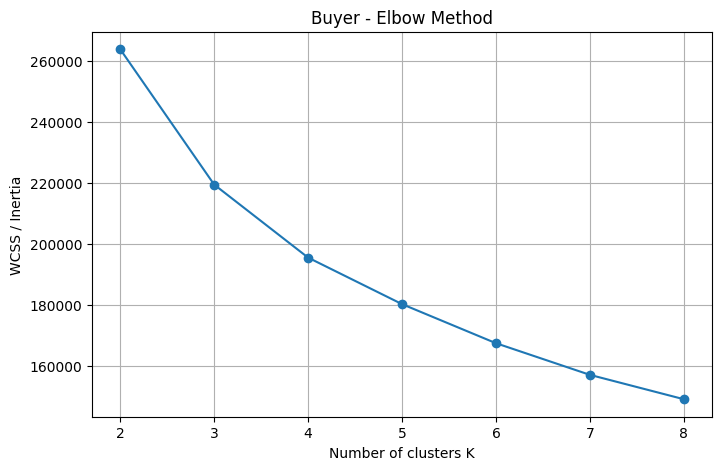

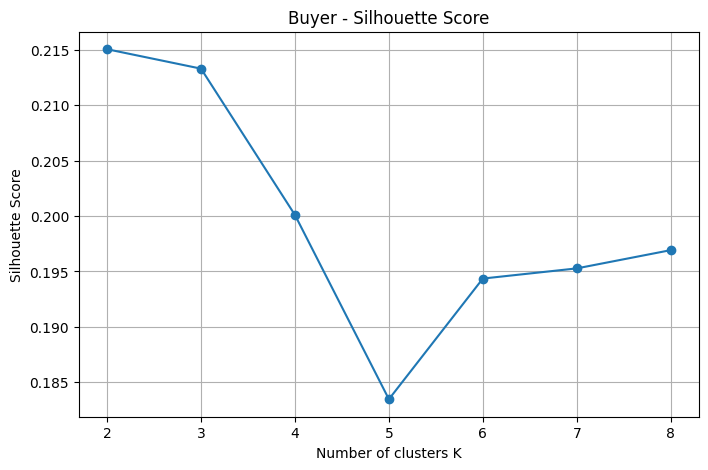

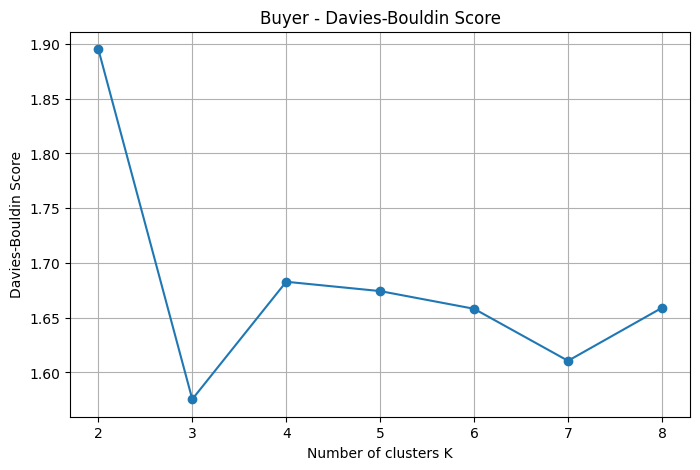

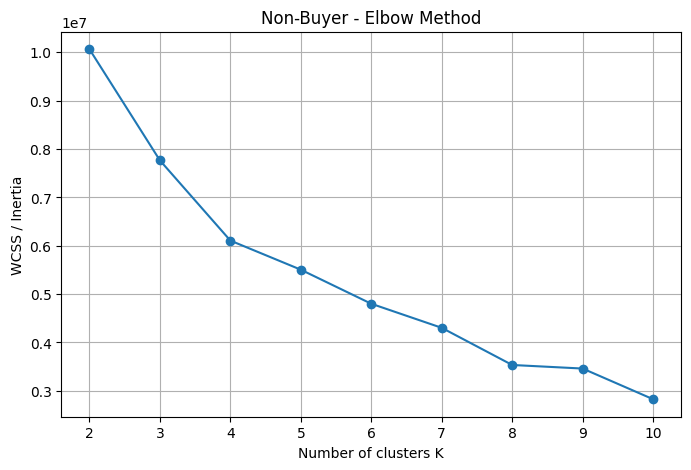

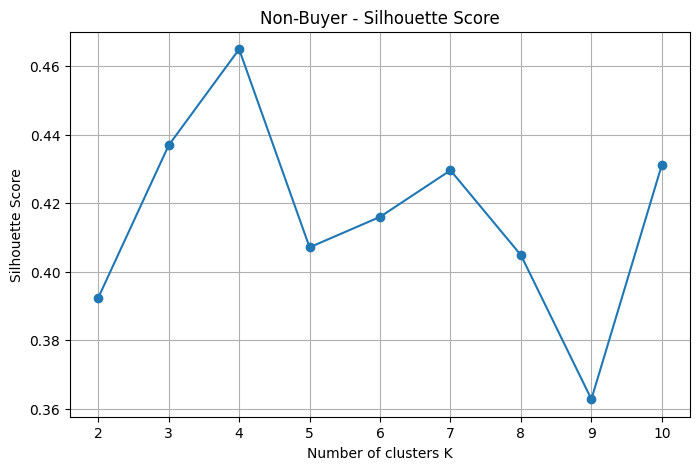

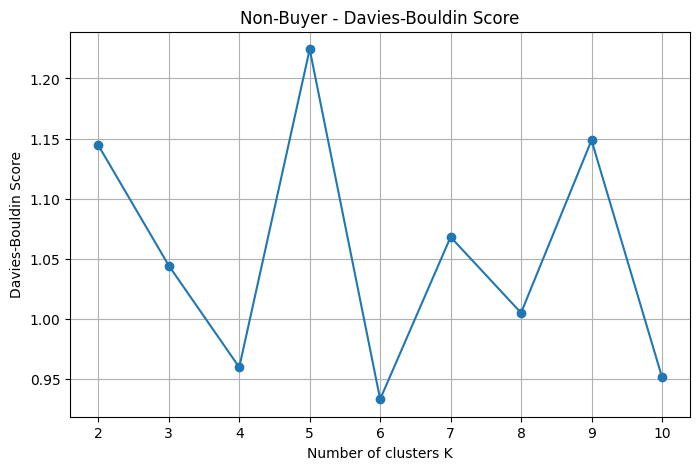

In [45]:
# ============================================================
# PLOT K EVALUATION
# ============================================================

import matplotlib.pyplot as plt

def plot_k_eval(k_eval, title_prefix):
    plt.figure(figsize=(8, 5))
    plt.plot(k_eval["k"], k_eval["WCSS_inertia"], marker="o")
    plt.xlabel("Number of clusters K")
    plt.ylabel("WCSS / Inertia")
    plt.title(f"{title_prefix} - Elbow Method")
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(k_eval["k"], k_eval["Silhouette"], marker="o")
    plt.xlabel("Number of clusters K")
    plt.ylabel("Silhouette Score")
    plt.title(f"{title_prefix} - Silhouette Score")
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(k_eval["k"], k_eval["Davies_Bouldin"], marker="o")
    plt.xlabel("Number of clusters K")
    plt.ylabel("Davies-Bouldin Score")
    plt.title(f"{title_prefix} - Davies-Bouldin Score")
    plt.grid(True)
    plt.show()


plot_k_eval(buyer_k_eval, "Buyer")
plot_k_eval(nonbuyer_k_eval, "Non-Buyer")

In [74]:
# ============================================================
# ELBOW ANALYSIS: WCSS DROP AND RELATIVE IMPROVEMENT
# ============================================================

elbow_df = buyer_k_eval.copy()

elbow_df["WCSS_drop"] = elbow_df["WCSS_inertia"].diff(-1).abs()
elbow_df["WCSS_drop_pct"] = (
    elbow_df["WCSS_drop"] / elbow_df["WCSS_inertia"] * 100
).round(2)

elbow_df["next_WCSS_drop_pct"] = elbow_df["WCSS_drop_pct"].shift(-1)

display(elbow_df)

,k,WCSS_inertia,Silhouette,Davies_Bouldin,Calinski_Harabasz,WCSS_drop,WCSS_drop_pct,next_WCSS_drop_pct
0,2,226401.116046,0.223074,1.785311,4252.179802,44268.014882,19.55,12.23
1,3,182133.101164,0.233680,1.454407,4380.487779,22270.820714,12.23,9.38
2,4,159862.280449,0.224443,1.564095,3990.938270,15001.521357,9.38,7.22
3,5,144860.759092,0.216931,1.521983,3673.116211,10454.745872,7.22,7.30
4,6,134406.013220,0.217094,1.466798,3389.261221,9805.530159,7.30,5.58
5,7,124600.483061,0.221524,1.549778,3233.940042,6955.960810,5.58,NaN
6,8,117644.522250,0.223075,1.509187,3056.390058,NaN,NaN,NaN


In [76]:
BUYER_FINAL_K = 3

In [77]:
# ============================================================
# ELBOW ANALYSIS: WCSS DROP AND RELATIVE IMPROVEMENT
# ============================================================

elbow_df = nonbuyer_k_eval.copy()

elbow_df["WCSS_drop"] = elbow_df["WCSS_inertia"].diff(-1).abs()
elbow_df["WCSS_drop_pct"] = (
    elbow_df["WCSS_drop"] / elbow_df["WCSS_inertia"] * 100
).round(2)

elbow_df["next_WCSS_drop_pct"] = elbow_df["WCSS_drop_pct"].shift(-1)

display(elbow_df)

,k,WCSS_inertia,Silhouette,Davies_Bouldin,Calinski_Harabasz,WCSS_drop,WCSS_drop_pct,next_WCSS_drop_pct
0,2,9.633645e+06,0.413050,1.105859,18748.728815,2.299679e+06,23.87,22.61
1,3,7.333967e+06,0.464061,1.010475,17122.635241,1.657893e+06,22.61,10.39
2,4,5.676074e+06,0.495510,0.926269,17617.201176,5.897973e+05,10.39,15.27
3,5,5.086276e+06,0.427885,1.212710,15562.484142,7.764789e+05,15.27,12.78
4,6,4.309798e+06,0.424810,1.096007,15819.298521,5.506164e+05,12.78,11.00
5,7,3.759181e+06,0.450708,1.009731,15825.525591,4.136469e+05,11.00,18.95
6,8,3.345534e+06,0.462863,0.953409,15794.209888,6.340115e+05,18.95,12.31
7,9,2.711523e+06,0.491825,0.839645,18021.031691,3.338920e+05,12.31,NaN
8,10,2.377631e+06,0.510775,0.879098,18642.549126,NaN,NaN,NaN


In [78]:
NONBUYER_FINAL_K = 4

In [79]:
buyer_final_k = 3
nonbuyer_final_k = 4

In [80]:
# ============================================================
# TRAIN FINAL K-MEANS FOR BUYER AND NON-BUYER GROUPS
# buyer_final_k = 3
# nonbuyer_final_k = 4
# Input:
#   buyer_scored
#   nonbuyer_scored
#   buyer_kmeans_score_features
#   nonbuyer_kmeans_score_features
# Output:
#   buyer_clustered
#   nonbuyer_clustered
#   all_clustered
# ============================================================

import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans, MiniBatchKMeans

buyer_final_k = 3
nonbuyer_final_k = 4


# ============================================================
# 1. Helper function: train final K-Means
# ============================================================

def train_final_kmeans_on_scores(
    df,
    features,
    final_k,
    cluster_col,
    use_minibatch=False,
    batch_size=10000,
    random_state=42
):
    df = df.copy()

    # Keep only existing features
    features = [c for c in features if c in df.columns]

    if len(features) == 0:
        raise ValueError(f"No valid features found for {cluster_col}")

    print(f"\nTraining {cluster_col}")
    print("Final K:", final_k)
    print("Features:", features)

    # Prepare X
    X_raw = df[features].copy()

    for col in features:
        X_raw[col] = pd.to_numeric(X_raw[col], errors="coerce")

    # Since all features are 1-5 scores, only impute missing values
    preprocess = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
    ])

    X_ready = preprocess.fit_transform(X_raw)

    # Train K-Means
    if use_minibatch:
        model = MiniBatchKMeans(
            n_clusters=final_k,
            init="k-means++",
            batch_size=batch_size,
            n_init=10,
            random_state=random_state,
            max_iter=300
        )
    else:
        model = KMeans(
            n_clusters=final_k,
            init="k-means++",
            n_init=10,
            random_state=random_state,
            max_iter=300
        )

    df[cluster_col] = model.fit_predict(X_ready)

    # Print distribution
    print("\nCluster counts:")
    display(df[cluster_col].value_counts().sort_index())

    print("\nCluster percentage:")
    display(
        df[cluster_col]
        .value_counts(normalize=True)
        .sort_index()
        .mul(100)
        .round(2)
    )

    return df, model, preprocess, X_ready, features


# ============================================================
# 2. Train Buyer K-Means
# ============================================================

buyer_clustered, buyer_kmeans_model, buyer_preprocess, X_buyer_ready, buyer_final_features = (
    train_final_kmeans_on_scores(
        df=buyer_scored,
        features=buyer_kmeans_score_features,
        final_k=buyer_final_k,
        cluster_col="Buyer_Cluster",
        use_minibatch=False,
        random_state=42
    )
)


# ============================================================
# 3. Train Non-Buyer K-Means
# ============================================================

nonbuyer_clustered, nonbuyer_kmeans_model, nonbuyer_preprocess, X_nonbuyer_ready, nonbuyer_final_features = (
    train_final_kmeans_on_scores(
        df=nonbuyer_scored,
        features=nonbuyer_kmeans_score_features,
        final_k=nonbuyer_final_k,
        cluster_col="NonBuyer_Cluster",
        use_minibatch=True,
        batch_size=10000,
        random_state=42
    )
)


Training Buyer_Cluster
Final K: 3
Features: ['R_score', 'F_score', 'M_score', 'L_score', 'E_score', 'Bounce_score', 'SessionQualityMean_score', 'SessionQualityMax_score', 'Funnel_score', 'Evening_score']

Cluster counts:


Buyer_Cluster
0    5713
1    4175
2    4415
Name: count, dtype: int64


Cluster percentage:


Buyer_Cluster
0    39.94
1    29.19
2    30.87
Name: proportion, dtype: float64


Training NonBuyer_Cluster
Final K: 4
Features: ['R_score', 'E_score', 'F_score', 'L_score', 'Bounce_score', 'SessionQualityMean_score', 'SessionQualityMax_score', 'Funnel_score', 'Hibernation_score']

Cluster counts:


NonBuyer_Cluster
0    134894
1    461504
2    573737
3     88510
Name: count, dtype: int64


Cluster percentage:


NonBuyer_Cluster
0    10.72
1    36.67
2    45.58
3     7.03
Name: proportion, dtype: float64

In [81]:
# ============================================================
# PROFILE BUYER CLUSTERS
# ============================================================

buyer_profile_cols = buyer_final_features + [
    "R_recency",
    "F_frequency",
    "M_monetary",
    "M_monetary_log1p",
    "L_length",
    "E_engagement",
    "totals_bounces_mean",
    "totals_sessionQualityDim_mean",
    "totals_sessionQualityDim_max",
    "funnel_depth",
    "pct_weekend",
    "pct_evening",
    "hibernation_flag",
    "vel_pageviews",
    "vel_hits",
    "vel_sessions",
    "RFM_total",
    "LRFM_total",
    "Full_behavior_score",
]

buyer_profile_cols = [
    c for c in buyer_profile_cols
    if c in buyer_clustered.columns
]

buyer_cluster_size = (
    buyer_clustered
    .groupby("Buyer_Cluster")
    .size()
    .rename("n_customers")
)

buyer_cluster_pct = (
    buyer_clustered
    .groupby("Buyer_Cluster")
    .size()
    .pipe(lambda s: s / s.sum() * 100)
    .rename("customer_share_pct")
    .round(2)
)

buyer_revenue_share = (
    buyer_clustered
    .groupby("Buyer_Cluster")["M_monetary"]
    .sum()
    .pipe(lambda s: s / s.sum() * 100)
    .rename("revenue_share_pct")
    .round(2)
)

buyer_profile_median = (
    buyer_clustered
    .groupby("Buyer_Cluster")[buyer_profile_cols]
    .median()
    .round(2)
)

buyer_cluster_summary = (
    pd.concat(
        [
            buyer_cluster_size,
            buyer_cluster_pct,
            buyer_revenue_share,
            buyer_profile_median
        ],
        axis=1
    )
    .reset_index()
)

display(buyer_cluster_summary)

,Buyer_Cluster,n_customers,customer_share_pct,revenue_share_pct,R_score,F_score,M_score,L_score,E_score,Bounce_score,...,funnel_depth,pct_weekend,pct_evening,hibernation_flag,vel_pageviews,vel_hits,vel_sessions,RFM_total,LRFM_total,Full_behavior_score
0,0,5713,39.94,26.16,2.0,2.0,3.0,1.0,3.0,5.0,...,22.50,0.0,0.00,1.0,1.0,1.0,1.0,7.0,8.0,29.0
1,1,4175,29.19,17.39,4.0,2.0,3.0,1.0,2.0,5.0,...,21.00,0.0,0.00,1.0,1.0,1.0,1.0,9.0,10.0,38.0
2,2,4415,30.87,56.45,3.0,5.0,4.0,4.0,4.0,1.0,...,12.87,0.0,0.25,1.0,1.0,1.0,1.0,11.0,15.0,36.0


In [82]:
# ============================================================
# CHECK SCORE FEATURES THAT DO NOT DIFFER ACROSS BUYER CLUSTERS
# ============================================================

score_cols = [
    "R_score",
    "F_score",
    "M_score",
    "L_score",
    "E_score",
    "Bounce_score",
    "SessionQualityMean_score",
    "SessionQualityMax_score",
    "Funnel_score",
    "Weekend_score",
    "Evening_score",
    "Hibernation_score",
    "VelocityPageviews_score",
    "VelocityHits_score",
    "VelocitySessions_score",
]

score_cols = [c for c in score_cols if c in buyer_clustered.columns]

cluster_medians = (
    buyer_clustered
    .groupby("Buyer_Cluster")[score_cols]
    .median()
)

feature_diff = []

for col in score_cols:
    medians = cluster_medians[col]
    feature_diff.append({
        "feature": col,
        "cluster_median_min": medians.min(),
        "cluster_median_max": medians.max(),
        "median_range": medians.max() - medians.min(),
        "unique_cluster_medians": medians.nunique()
    })

feature_diff_df = pd.DataFrame(feature_diff).sort_values(
    ["median_range", "unique_cluster_medians"],
    ascending=[True, True]
)

display(feature_diff_df)

,feature,cluster_median_min,cluster_median_max,median_range,unique_cluster_medians
9,Weekend_score,1.0,1.0,0.0,1
11,Hibernation_score,1.0,1.0,0.0,1
12,VelocityPageviews_score,1.0,1.0,0.0,1
13,VelocityHits_score,1.0,1.0,0.0,1
14,VelocitySessions_score,1.0,1.0,0.0,1
2,M_score,3.0,4.0,1.0,2
8,Funnel_score,3.0,4.0,1.0,2
10,Evening_score,1.0,2.0,1.0,2
0,R_score,2.0,4.0,2.0,3
4,E_score,2.0,4.0,2.0,3


In [83]:
# ============================================================
# CHECK SCORE FEATURES THAT DO NOT DIFFER ACROSS BUYER CLUSTERS
# ============================================================

score_cols = [
    "R_score",
    "F_score",
    "M_score",
    "L_score",
    "E_score",
    "Bounce_score",
    "SessionQualityMean_score",
    "SessionQualityMax_score",
    "Funnel_score",
    "Weekend_score",
    "Evening_score",
    "Hibernation_score",
    "VelocityPageviews_score",
    "VelocityHits_score",
    "VelocitySessions_score",
]

score_cols = [c for c in score_cols if c in nonbuyer_clustered.columns]

cluster_medians = (
    nonbuyer_clustered
    .groupby("NonBuyer_Cluster")[score_cols]
    .median()
)

feature_diff = []

for col in score_cols:
    medians = cluster_medians[col]
    feature_diff.append({
        "feature": col,
        "cluster_median_min": medians.min(),
        "cluster_median_max": medians.max(),
        "median_range": medians.max() - medians.min(),
        "unique_cluster_medians": medians.nunique()
    })

feature_diff_df = pd.DataFrame(feature_diff).sort_values(
    ["median_range", "unique_cluster_medians"],
    ascending=[True, True]
)

display(feature_diff_df)

,feature,cluster_median_min,cluster_median_max,median_range,unique_cluster_medians
1,F_score,1.0,1.0,0.0,1
2,L_score,1.0,1.0,0.0,1
8,Weekend_score,1.0,1.0,0.0,1
9,Evening_score,1.0,1.0,0.0,1
11,VelocityPageviews_score,1.0,1.0,0.0,1
12,VelocityHits_score,1.0,1.0,0.0,1
13,VelocitySessions_score,1.0,1.0,0.0,1
4,Bounce_score,3.0,5.0,2.0,2
6,SessionQualityMax_score,1.0,3.0,2.0,2
0,R_score,2.0,5.0,3.0,4


In [84]:
# ============================================================
# PROFILE NON-BUYER CLUSTERS
# ============================================================

nonbuyer_profile_cols = nonbuyer_final_features + [
    "R_recency",
    "F_frequency",
    "L_length",
    "E_engagement",
    "totals_bounces_mean",
    "totals_sessionQualityDim_mean",
    "totals_sessionQualityDim_max",
    "funnel_depth",
    "pct_weekend",
    "pct_evening",
    "hibernation_flag",
    "vel_pageviews",
    "vel_hits",
    "vel_sessions",
    "RF_total",
    "LRF_total",
    "Full_behavior_score",
]

nonbuyer_profile_cols = [
    c for c in nonbuyer_profile_cols
    if c in nonbuyer_clustered.columns
]

nonbuyer_cluster_size = (
    nonbuyer_clustered
    .groupby("NonBuyer_Cluster")
    .size()
    .rename("n_customers")
)

nonbuyer_cluster_pct = (
    nonbuyer_clustered
    .groupby("NonBuyer_Cluster")
    .size()
    .pipe(lambda s: s / s.sum() * 100)
    .rename("customer_share_pct")
    .round(2)
)

nonbuyer_profile_median = (
    nonbuyer_clustered
    .groupby("NonBuyer_Cluster")[nonbuyer_profile_cols]
    .median()
    .round(2)
)

nonbuyer_cluster_summary = (
    pd.concat(
        [
            nonbuyer_cluster_size,
            nonbuyer_cluster_pct,
            nonbuyer_profile_median
        ],
        axis=1
    )
    .reset_index()
)

display(nonbuyer_cluster_summary)

,NonBuyer_Cluster,n_customers,customer_share_pct,R_score,E_score,F_score,L_score,Bounce_score,SessionQualityMean_score,SessionQualityMax_score,...,funnel_depth,pct_weekend,pct_evening,hibernation_flag,vel_pageviews,vel_hits,vel_sessions,RF_total,LRF_total,Full_behavior_score
0,0,134894,10.72,5.0,1.0,1.0,1.0,3.0,2.0,1.0,...,1.0,0.0,0.0,0.0,0.5,0.5,0.5,6.0,7.0,29.0
1,1,461504,36.67,2.0,4.0,1.0,1.0,5.0,1.0,1.0,...,3.0,0.0,0.0,1.0,1.0,1.0,1.0,4.0,5.0,26.0
2,2,573737,45.58,3.0,1.0,1.0,1.0,3.0,1.0,1.0,...,1.0,0.0,0.0,1.0,1.0,1.0,1.0,4.0,5.0,19.0
3,3,88510,7.03,4.0,5.0,1.0,1.0,5.0,5.0,3.0,...,10.0,0.0,0.0,1.0,1.0,1.0,1.0,6.0,7.0,38.0


In [86]:
def assign_buyer_segment_name(row):
    r = row.get("R_score", np.nan)
    f = row.get("F_score", np.nan)
    m = row.get("M_score", np.nan)
    e = row.get("E_score", np.nan)
    rev_share = row.get("revenue_share_pct", 0)
    customer_share = row.get("customer_share_pct", 0)

    # 1. Nhóm đóng góp doanh thu vượt trội
    if f >= 4 and m >= 4 and rev_share > customer_share:
        return "Loyal High-Value Buyers"

    # 2. Mới mua gần đây nhưng chưa mua thường xuyên
    elif r >= 4 and f <= 2 and m >= 3:
        return "Recent Occasional Buyers"

    # 3. Lâu chưa quay lại, giá trị trung bình
    elif r <= 2 and f <= 2 and m >= 3:
        return "At-Risk Moderate Buyers"

    # 4. Lâu chưa quay lại nhưng từng mua nhiều/cao
    elif r <= 2 and f >= 4 and m >= 4:
        return "At-Risk High-Value Buyers"

    # 5. Mới mua, ít tiền
    elif r >= 4 and f <= 2 and m <= 2:
        return "New Low-Value Buyers"

    # 6. Mua đều, tương tác tốt
    elif f >= 3 and m >= 3 and e >= 3:
        return "Loyal Buyers"

    else:
        return "Regular Buyers"


buyer_cluster_summary["Buyer_Segment_Name"] = buyer_cluster_summary.apply(
    assign_buyer_segment_name,
    axis=1
)

buyer_name_map = dict(
    zip(
        buyer_cluster_summary["Buyer_Cluster"],
        buyer_cluster_summary["Buyer_Segment_Name"]
    )
)

buyer_clustered["Buyer_Segment_Name"] = buyer_clustered["Buyer_Cluster"].map(buyer_name_map)

display(
    buyer_cluster_summary[
        [
            "Buyer_Cluster",
            "Buyer_Segment_Name",
            "n_customers",
            "customer_share_pct",
            "revenue_share_pct",
            "R_score",
            "F_score",
            "M_score",
            "E_score"
        ]
    ]
)

,Buyer_Cluster,Buyer_Segment_Name,n_customers,customer_share_pct,revenue_share_pct,R_score,F_score,M_score,E_score
0,0,At-Risk Moderate Buyers,5713,39.94,26.16,2.0,2.0,3.0,3.0
1,1,Recent Occasional Buyers,4175,29.19,17.39,4.0,2.0,3.0,2.0
2,2,Loyal High-Value Buyers,4415,30.87,56.45,3.0,5.0,4.0,4.0


In [88]:
# ============================================================
# BUSINESS NAMING FOR NON-BUYER CLUSTERS
# ============================================================

def assign_nonbuyer_segment_name(row):
    r = row.get("R_score", np.nan)
    f = row.get("F_score", np.nan)
    e = row.get("E_score", np.nan)
    bounce = row.get("Bounce_score", np.nan)
    funnel = row.get("Funnel_score", np.nan)
    quality = row.get("SessionQualityMean_score", np.nan)
    h = row.get("Hibernation_score", np.nan)

    if r >= 4 and e >= 4 and funnel >= 4 and bounce >= 4:
        return "Hot Prospects"

    elif r >= 4 and e >= 3 and funnel >= 3:
        return "Warm Prospects"

    elif r >= 4 and f <= 2 and e <= 2:
        return "New Low-Intent Visitors"

    elif r <= 2 and h <= 2:
        return "Dormant Engaged Non-Buyers"

    elif e >= 4 and bounce <= 2:
        return "Browsers with Friction"

    elif quality >= 4 and funnel >= 3:
        return "High-Quality Researchers"

    else:
        return "General Non-Buyers"


nonbuyer_cluster_summary["NonBuyer_Segment_Name"] = nonbuyer_cluster_summary.apply(
    assign_nonbuyer_segment_name,
    axis=1
)

nonbuyer_name_map = dict(
    zip(
        nonbuyer_cluster_summary["NonBuyer_Cluster"],
        nonbuyer_cluster_summary["NonBuyer_Segment_Name"]
    )
)

nonbuyer_clustered["NonBuyer_Segment_Name"] = nonbuyer_clustered["NonBuyer_Cluster"].map(nonbuyer_name_map)

display(
    nonbuyer_cluster_summary[
        [
            "NonBuyer_Cluster",
            "NonBuyer_Segment_Name",
            "n_customers",
            "customer_share_pct",
            "R_score",
            "F_score",
            "E_score",
            "Bounce_score",
            "Funnel_score",
        ]
    ]
)

,NonBuyer_Cluster,NonBuyer_Segment_Name,n_customers,customer_share_pct,R_score,F_score,E_score,Bounce_score,Funnel_score
0,0,New Low-Intent Visitors,134894,10.72,5.0,1.0,1.0,3.0,1.0
1,1,Dormant Engaged Non-Buyers,461504,36.67,2.0,1.0,4.0,5.0,3.0
2,2,General Non-Buyers,573737,45.58,3.0,1.0,1.0,3.0,1.0
3,3,Hot Prospects,88510,7.03,4.0,1.0,5.0,5.0,5.0
